In [1]:
import pandas as pd
import numpy as np

In [3]:
from pytrends.request import TrendReq ###-----> Google Trend'ten veri çekmek 

### Google Trends sorgu için nesle oluşturuldu

In [4]:
pytrends = TrendReq(
    hl ="tr-TR",
    tz=0
)

In [5]:
keywords = ["LangChain"]

In [7]:
pytrends.build_payload(      ### build_payload ---> sorgu kapsamı
    kw_list=keywords,
    cat=0,
    timeframe="2023-08-11 2026-08-11",
    geo="",
    gprop=""
)

In [9]:
df = pytrends.interest_over_time()  ###---> Gerçek veri çekildi

In [10]:
df

,LangChain,isPartial
date,,
2023-08-06,25,False
2023-08-13,23,False
2023-08-20,24,False
2023-08-27,23,False
2023-09-03,22,False
...,...,...
2026-07-12,44,False
2026-07-19,50,False
2026-07-26,39,False


In [11]:
df.head()

,LangChain,isPartial
date,,
2023-08-06,25,False
2023-08-13,23,False
2023-08-20,24,False
2023-08-27,23,False
2023-09-03,22,False


In [21]:
df.tail()

,LangChain,isPartial
date,,
2026-07-12,43,False
2026-07-19,47,False
2026-07-26,38,False
2026-08-02,27,False
2026-08-09,24,True


In [12]:
df.shape

(158, 2)

In [13]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 158 entries, 2023-08-06 to 2026-08-09
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LangChain  158 non-null    int64
 1   isPartial  158 non-null    bool 
dtypes: bool(1), int64(1)
memory usage: 2.6 KB


In [17]:
df.to_csv(
    "../data/raw/langchain_global_raw.csv"
)

In [15]:
df.index.min()

Timestamp('2023-08-06 00:00:00')

In [16]:
df.index.max()

Timestamp('2026-08-09 00:00:00')

In [19]:
pd.infer_freq(df.index) ### ----> Verinin haftalık olduğu bulundu W --> Weekly / SUN --> Sunday

'W-SUN'

In [20]:
df.index.to_series().diff().value_counts() ### Doğrulama işlemi 

date
7 days    157
Name: count, dtype: int64

In [23]:
df.isnull().sum()  ### NaN kontrolü ama tarih kayıp ise yetersiz işlem

LangChain    0
isPartial    0
dtype: int64

In [24]:
df.index.duplicated().sum() ### Tarih tekrarı kontrolü 

np.int64(0)

In [25]:
(df["LangChain"] == 0).sum() 

np.int64(0)

In [26]:
df["LangChain"].describe()

count    158.000000
mean      43.955696
std       22.355080
min       18.000000
25%       28.000000
50%       33.000000
75%       64.750000
max      100.000000
Name: LangChain, dtype: float64

In [27]:
df.to_csv(
    "../data/raw/langchain_global_raw.csv"
)

In [30]:
### teorik olarak olması gereken tarih takvimi oluşturuldu çünkü eksik tarih verisini daha basit gözlemyebilmek için
full_index = pd.date_range(    ### date_range --> düzenli tarih dizisi oluşturur
    start=df.index.min(),
    end=df.index.max()
)

full_index

DatetimeIndex(['2023-08-06', '2023-08-07', '2023-08-08', '2023-08-09',
               '2023-08-10', '2023-08-11', '2023-08-12', '2023-08-13',
               '2023-08-14', '2023-08-15',
               ...
               '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03',
               '2026-08-04', '2026-08-05', '2026-08-06', '2026-08-07',
               '2026-08-08', '2026-08-09'],
              dtype='datetime64[s]', length=1100, freq='D')

In [33]:
freq = pd.infer_freq(df.index) ### Zaman serisinin hangi frekansta ilerlediğini otomatik tespit ediyoruz

print("Tespit edilen frekans:", freq)

Tespit edilen frekans: W-SUN


In [34]:
### Veri setinin ilk ve son atrihi arasında buluması gereken tüm haftalık tarihleri oluşturuyoruz
### Amaç ise Gerçek veri içerisinde tamamen kayıp olan bir hafta varsa daha sonra buun tespit edebilmek

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq=freq
)

In [36]:
expected_count = len(full_index) ### teorik olarak bu zaman aralığında 158 hafta gözlem olması gerekiyor
print("Beklenen gözlem sayısı:", expected_count)

Beklenen gözlem sayısı: 158


In [38]:
actual_count = len(df) ### Google Trend'ten çektiğimiz gerçek gözlem sayısını kontrol ediyoruz ama hala yeterli dğeil
print("gerçek gözlem sayısı:", actual_count)

gerçek gözlem sayısı: 158


## Neden hala yeterli değil ? 

##### " 1 Ocak, 8 Ocak, 15 Ocak, 22 Ocak " olması gerekirken gerçek veri " 1 Ocak, 8 Ocak, 22 Ocak, 29 ocak " 

##### Her ikisinde de 4 tarih var ama 15 Ocak eksik, 29 Ocak ise fazladan





In [46]:
missing_dates = full_index.difference(df.index)

In [47]:
missing_dates

DatetimeIndex([], dtype='datetime64[s]', freq='W-SUN')

In [48]:
len(missing_dates)

0

In [52]:
### Zaman serisinin haftalık frekansı kontrol edildi ve eksik timestamp tespit edilmedi.
### Bu nedenle interpolation uygulanmadı.

In [54]:
clean_df = df.copy()

In [55]:
clean_df = df.copy()

In [56]:
clean_df.head()

,LangChain,isPartial
date,,
2023-08-06,24,False
2023-08-13,24,False
2023-08-20,23,False
2023-08-27,21,False
2023-09-03,22,False


In [57]:
clean_df = clean_df.rename(
    columns={"LangChain": "trend_score"}
)

In [58]:
clean_df.head()

,trend_score,isPartial
date,,
2023-08-06,24,False
2023-08-13,24,False
2023-08-20,23,False
2023-08-27,21,False
2023-09-03,22,False


In [59]:
clean_df.index.name

'date'

In [60]:
clean_df.to_csv(
    "../data/processed/langchain_global_clean.csv"
)

In [61]:
#EDA

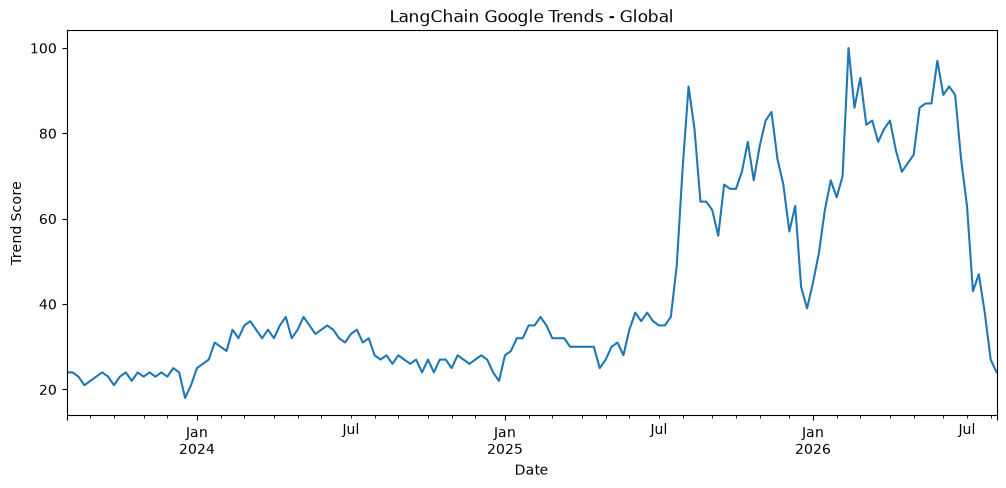

In [63]:
import matplotlib.pyplot as plt

clean_df["trend_score"].plot(figsize=(12,5))

plt.title("LangChain Google Trends - Global")
plt.xlabel("Date")
plt.ylabel("Trend Score")
plt.show()

In [64]:
clean_df["rolling_4"] = (
    clean_df["trend_score"]
    .rolling(window=4)
    .mean()
)

In [65]:
clean_df.head(10)

,trend_score,isPartial,rolling_4
date,,,
2023-08-06,24,False,NaN
2023-08-13,24,False,NaN
2023-08-20,23,False,NaN
2023-08-27,21,False,23.00
2023-09-03,22,False,22.50
2023-09-10,23,False,22.25
2023-09-17,24,False,22.50
2023-09-24,23,False,23.00
2023-10-01,21,False,22.75


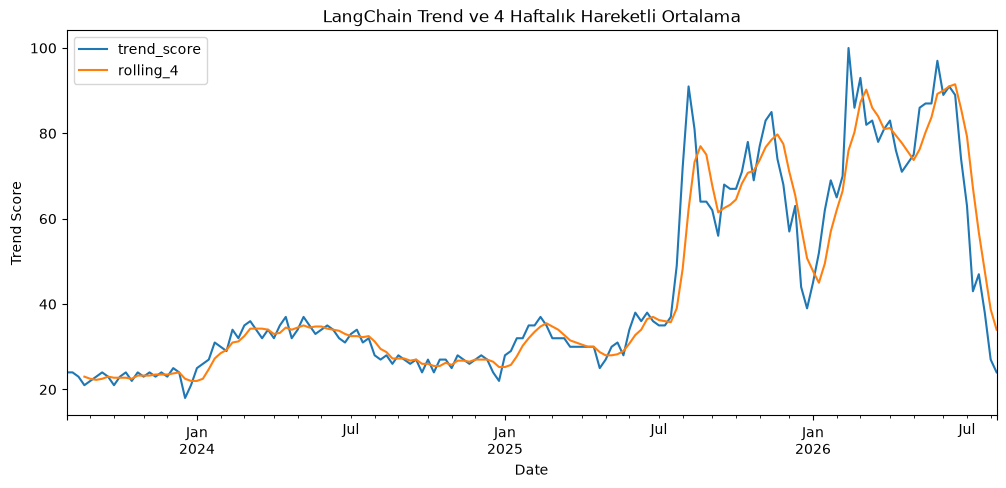

In [66]:
clean_df[
    ["trend_score", "rolling_4"]
].plot(figsize=(12, 5))

plt.title("LangChain Trend ve 4 Haftalık Hareketli Ortalama")
plt.xlabel("Date")
plt.ylabel("Trend Score")
plt.show()

In [67]:
clean_df["trend_score"].nlargest(10)

date
2026-02-15    100
2026-05-31     97
2026-03-01     93
2025-08-10     91
2026-06-14     91
2026-06-07     89
2026-06-21     89
2026-05-17     87
2026-05-24     87
2026-02-22     86
Name: trend_score, dtype: int64

In [68]:
clean_df["trend_score"].nsmallest(10)

date
2023-12-24    18
2023-08-27    21
2023-10-01    21
2023-12-31    21
2023-09-03    22
2023-10-22    22
2024-12-29    22
2023-08-20    23
2023-09-10    23
2023-09-24    23
Name: trend_score, dtype: int64

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [70]:
period=52

In [71]:
decomposition = seasonal_decompose(
    clean_df["trend_score"],
    model="additive",
    period=52
)

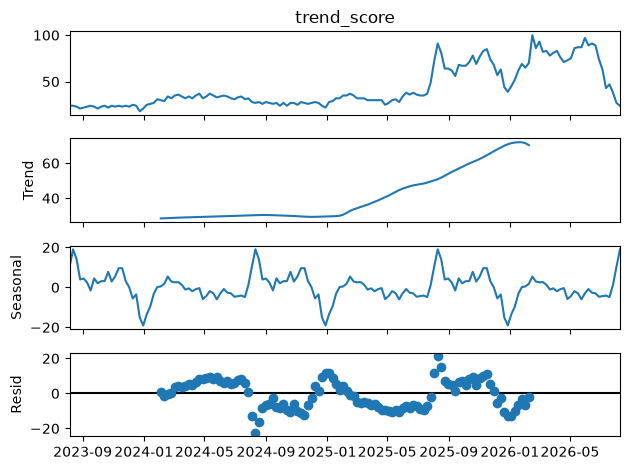

In [72]:
decomposition.plot()
plt.show()